## Imports + Config


In [27]:
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

SCRIPT = "matmul_multi_device_split_optimized.py"
N = 8192
ALPHAS = np.arange(0.8, 1.01, 0.1)
RUNS = 3
WARMUP = 1

SCRIPT = os.path.abspath(SCRIPT)
if not os.path.isfile(SCRIPT):
    raise FileNotFoundError(f"Script not found: {SCRIPT}")
print(f"Using script: {SCRIPT}")


Using script: c:\Users\medte\OneDrive\Desktop\Codesign_tp\TP-CODESIGN\opencl_examples\multi_device_optimized_both\matmul_multi_device_split_optimized.py


## Regex Parsers


In [28]:
GLOBAL_GFLOPS_RE = r"Global GFLOPS:\s+([0-9.]+)"
TOTAL_TIME_RE = r"Total time.*:\s+([0-9.]+)"
MEAN_TIME_RE = r"Mean time per run.*:\s+([0-9.]+)"
BASELINE_TOTAL_TIME_RE = r"Baseline NVIDIA-only time:\s+([0-9.]+)"
BASELINE_MEAN_TIME_RE = r"Baseline NVIDIA-only mean time(?: per run)?:\s+([0-9.]+)"


## Run Function


In [29]:
def _extract_float(pattern, text, label, required=True):
    m = re.search(pattern, text)
    if m is None:
        if required:
            raise RuntimeError(f"Missing {label} in script output")
        return None
    return float(m.group(1))

def _extract_t_mean(total_re, mean_re, text, label):
    mean_val = _extract_float(mean_re, text, f"{label} mean time", required=False)
    if mean_val is not None:
        return mean_val
    total_val = _extract_float(total_re, text, f"{label} total time", required=True)
    return total_val / RUNS

def run_alpha(alpha):
    cmd = [
        "python", SCRIPT,
        "--n", str(N),
        "--alpha", str(float(alpha)),
        "--runs", str(RUNS),
        "--warmup", str(WARMUP)
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"Command failed for alpha={alpha}\nSTDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}"
        )

    out = result.stdout
    t_mean = _extract_t_mean(TOTAL_TIME_RE, MEAN_TIME_RE, out, "split")
    baseline_t_mean = _extract_t_mean(BASELINE_TOTAL_TIME_RE, BASELINE_MEAN_TIME_RE, out, "baseline")

    gflops = (2.0 * (N ** 3)) / (t_mean * 1e9)
    speedup_vs_nvidia_same_timing = baseline_t_mean / t_mean
    reported_global_gflops = _extract_float(GLOBAL_GFLOPS_RE, out, "Global GFLOPS", required=False)

    return {
        "alpha": alpha,
        "gflops": gflops,
        "time": t_mean,
        "speedup_vs_nvidia_same_timing": speedup_vs_nvidia_same_timing,
        "reported_global_gflops": reported_global_gflops
    }


## Sweep Alpha


In [30]:
results = []

for alpha in ALPHAS:
    print(f"Running alpha={alpha:.1f}")
    results.append(run_alpha(alpha))

df = pd.DataFrame(results)
df


Running alpha=0.8
Running alpha=0.9
Running alpha=1.0


,alpha,gflops,time,speedup_vs_nvidia_same_timing,reported_global_gflops
0,0.8,1865.672378,0.589338,0.882490,1865.67
1,0.9,2340.252834,0.469826,1.107959,2340.25
2,1.0,2113.478115,0.520238,1.001603,2113.48


## Baselines


In [31]:
baseline_nvidia_uncoalesced = 121.13
baseline_nvidia_coalesced = 528.27
baseline_nvidia_optimized = 2148.0


## Speedups


In [32]:
df["speedup_vs_uncoalesced"] = df["gflops"] / baseline_nvidia_uncoalesced
df["speedup_vs_coalesced"] = df["gflops"] / baseline_nvidia_coalesced
df["speedup_vs_nvidia_opt"] = df["gflops"] / baseline_nvidia_optimized
df


,alpha,gflops,time,speedup_vs_nvidia_same_timing,reported_global_gflops,speedup_vs_uncoalesced,speedup_vs_coalesced,speedup_vs_nvidia_opt
0,0.8,1865.672378,0.589338,0.882490,1865.67,15.402232,3.531664,0.868563
1,0.9,2340.252834,0.469826,1.107959,2340.25,19.320175,4.430032,1.089503
2,1.0,2113.478115,0.520238,1.001603,2113.48,17.448015,4.000754,0.983928


## Plots


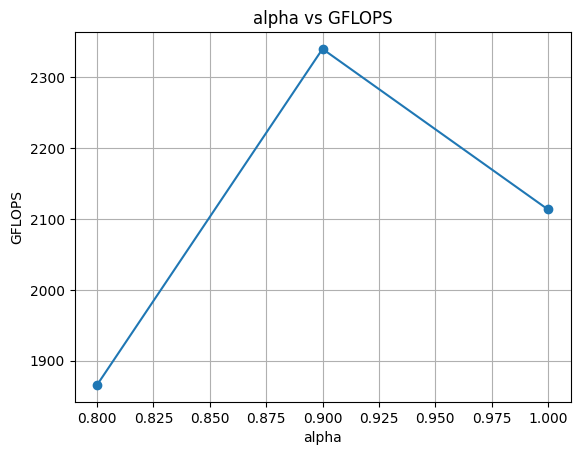

In [33]:
plt.figure()
plt.plot(df["alpha"], df["gflops"], marker="o")
plt.xlabel("alpha")
plt.ylabel("GFLOPS")
plt.title("alpha vs GFLOPS")
plt.grid()
plt.show()


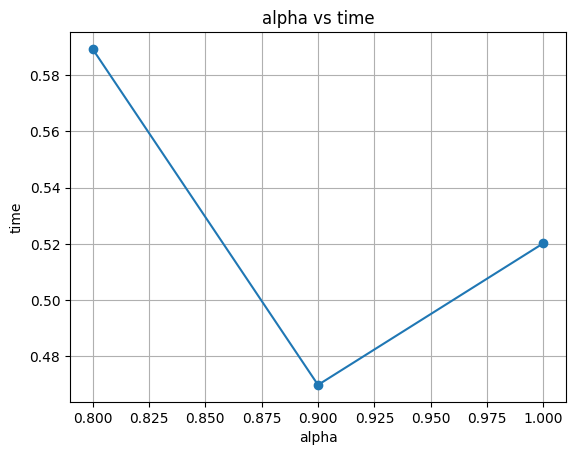

In [34]:
plt.figure()
plt.plot(df["alpha"], df["time"], marker="o")
plt.xlabel("alpha")
plt.ylabel("time")
plt.title("alpha vs time")
plt.grid()
plt.show()


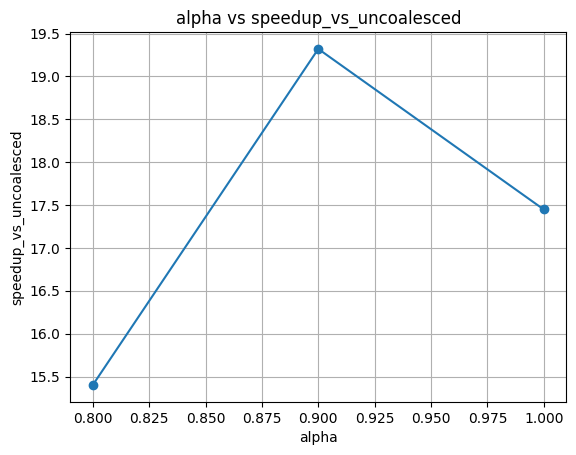

In [35]:
plt.figure()
plt.plot(df["alpha"], df["speedup_vs_uncoalesced"], marker="o")
plt.xlabel("alpha")
plt.ylabel("speedup_vs_uncoalesced")
plt.title("alpha vs speedup_vs_uncoalesced")
plt.grid()
plt.show()


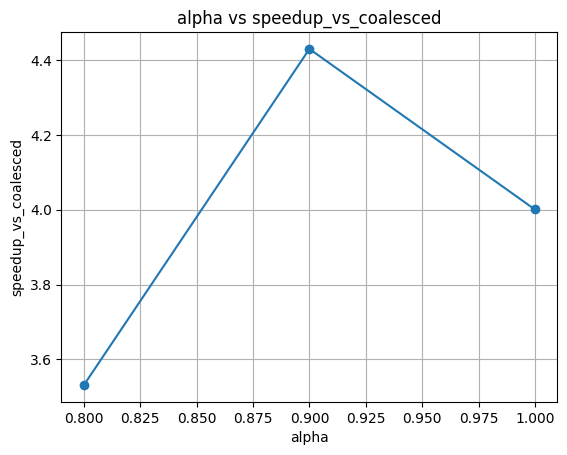

In [36]:
plt.figure()
plt.plot(df["alpha"], df["speedup_vs_coalesced"], marker="o")
plt.xlabel("alpha")
plt.ylabel("speedup_vs_coalesced")
plt.title("alpha vs speedup_vs_coalesced")
plt.grid()
plt.show()


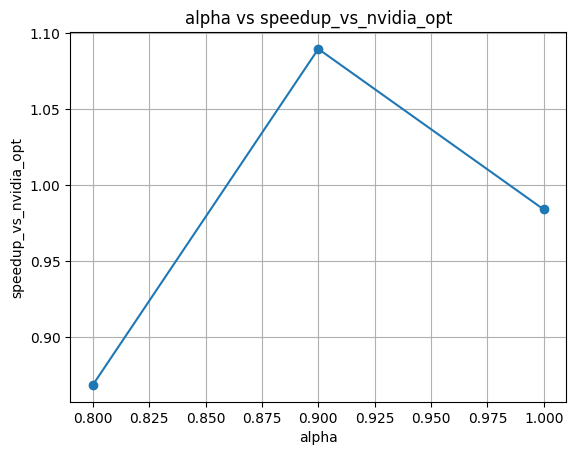

In [37]:
plt.figure()
plt.plot(df["alpha"], df["speedup_vs_nvidia_opt"], marker="o")
plt.xlabel("alpha")
plt.ylabel("speedup_vs_nvidia_opt")
plt.title("alpha vs speedup_vs_nvidia_opt")
plt.grid()
plt.show()


## Best Alpha


In [38]:
best = df.loc[df["gflops"].idxmax()]
print(f"best alpha: {best['alpha']:.1f}")
print(f"best gflops: {best['gflops']:.2f}")
print(f"best time: {best['time']:.6f}")
best


best alpha: 0.9
best gflops: 2340.25
best time: 0.469826


alpha                               0.900000
gflops                           2340.252834
time                                0.469826
speedup_vs_nvidia_same_timing       1.107959
reported_global_gflops           2340.250000
speedup_vs_uncoalesced             19.320175
speedup_vs_coalesced                4.430032
speedup_vs_nvidia_opt               1.089503
Name: 1, dtype: float64

## Save Results


In [39]:
df.to_csv("alpha_sweep_optimized_both.csv", index=False)
